In [88]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [89]:
import numpy as np
import matplotlib.pyplot as plt

In [90]:
df = fetch_california_housing()

In [91]:
dataset = pd.DataFrame(df.data)

In [92]:
dataset.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [93]:
dataset.columns = df.feature_names
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [94]:
X= dataset
y=df.target

In [95]:
len(y)

20640

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [98]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5088,0.9809,19.0,3.187726,1.129964,726.0,2.620939,33.98,-118.28
17096,4.2232,33.0,6.189696,1.086651,1015.0,2.377049,37.46,-122.23
5617,3.5488,42.0,4.821577,1.095436,1044.0,4.331950,33.79,-118.26
20060,1.6469,24.0,4.274194,1.048387,1686.0,4.532258,35.87,-119.26
895,3.9909,14.0,4.608303,1.089350,2738.0,2.471119,37.54,-121.96
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [99]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
15316,1.3269,19.0,3.987578,1.153209,1190.0,2.463768,33.20,-117.36
14772,2.7361,14.0,4.206612,0.983471,1224.0,3.371901,32.57,-117.07
12870,3.8355,15.0,6.419753,1.039781,2626.0,3.602195,38.71,-121.40
13476,4.3958,10.0,6.154506,1.013948,3528.0,3.785408,34.09,-117.39


In [100]:
from sklearn.linear_model import LinearRegression

In [101]:
model = LinearRegression()

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [104]:
from sklearn.model_selection import cross_val_score

In [105]:
mse = cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=5)

KeyboardInterrupt: 

In [ ]:
print(np.mean(mse))

-0.5230499763383936


In [ ]:
mse

array([-0.54099828, -0.49871687, -0.50480739, -0.5200183 , -0.55070903])

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

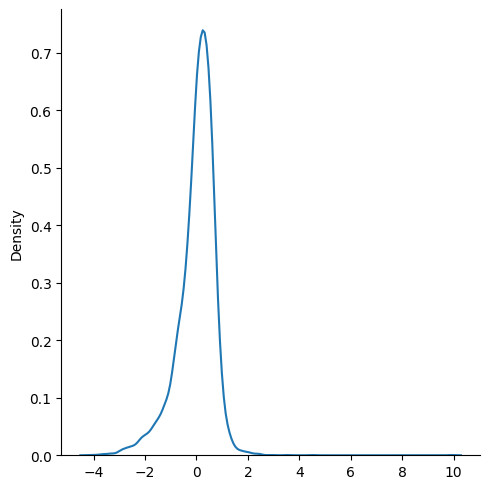

In [ ]:
import seaborn as sns
sns.displot(y_pred-y_test,kind='kde')

In [ ]:
from sklearn.metrics import r2_score


In [ ]:
r2_score(y_test,y_pred)

0.5970494128783952

### Ridge Regression
-   Used to solve overfitting
-   Tuning alpha(lambda) using GridSearchCV

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_regression=Ridge()

In [ ]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgeCv = GridSearchCV(ridge_regression,parameters,scoring='neg_mean_squared_error',cv=5)
ridgeCv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
print(ridgeCv.best_params_)

{'alpha': 5}


In [ ]:
print(ridgeCv.best_score_)

-0.5230459199911859


In [ ]:
print(ridgeCv.score)

<bound method BaseSearchCV.score of GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')>


In [ ]:
ridge_pred = ridgeCv.predict(X_test)

In [ ]:
r2_score(y_test,ridge_pred)

0.5971332254609972

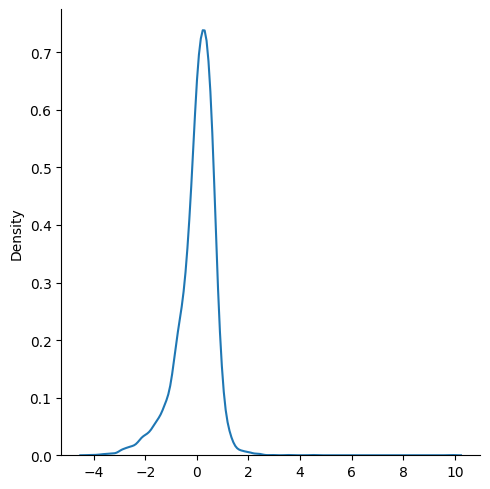

In [ ]:
sns.displot(ridge_pred-y_test,kind='kde')

### LASSO REGRESSION

In [106]:
from sklearn.linear_model import Lasso

In [107]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

In [108]:
lasso = Lasso()
lassocv = GridSearchCV(lasso,lasso_params,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train) 

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1]},
             scoring='neg_mean_squared_error')

In [109]:
lassocv.best_estimator_

Lasso(alpha=0.001)

In [110]:
lasso_pred = lassocv.predict(X_test)


In [111]:
r2_score(y_test,lasso_pred)

0.5976154285751365

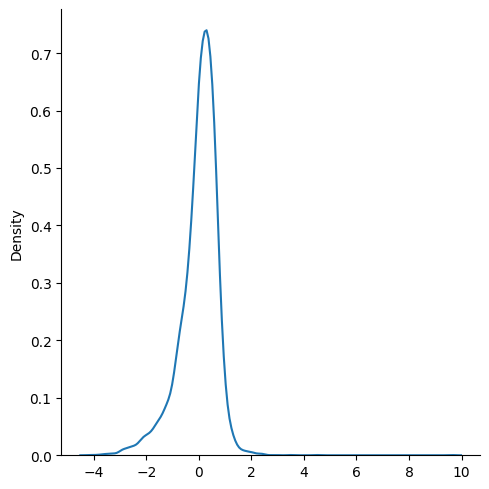

In [112]:
sns.displot(lasso_pred-y_test,kind='kde')